# SPIC test-rig data export — power load + weather

**SPIC = Single-Phase Immersion Cooling.** Exports one rack's power draw for one
day, rescaled into a small range (current config: **10–30**) matching what a
bench-scale heater/coupon on the immersion-cooling test rig can physically
dissipate — the rig sees the real rack's relative load profile, just scaled to its
own power budget. The matching outside temperature/humidity for that day is
exported separately, as the ambient heat-rejection boundary condition for the
cooling experiment.

Standalone utility — reads only `PM_COLS` / `DATA_ROOT` from `rack_forecast` for
consistency; does not modify or depend on the forecasting pipeline.

**Output**, two files per rack/date under `data_for_spic/`:
```
data_for_spic/{rack}_{date}/power_load.csv   timestamp, kW, kW_scaled
data_for_spic/{rack}_{date}/weather.csv      timestamp, outside_temp_C, outside_humidity_pct
```
Plus, optionally, a `.mat` export of any time window (see the last section) for
use directly in MATLAB/Simulink.

> `kW_scaled` is treated as **Watts for the test-rig heater** (real rack power is
> ~450–650 W, scaled down to whatever `[scale_min, scale_max]` the rig can
> dissipate — see Config below for the exact current range). If the rig actually
> expects a duty-cycle fraction or voltage rather than a direct Watt figure, adjust
> the column meaning/name below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from pathlib import Path

# Read-only reuse from the existing package — no edits to rack_forecast/.
from rack_forecast.data import PM_COLS, load_agg_pm
from rack_forecast.paths import DATA_ROOT, PROJECT_ROOT

print('DATA_ROOT:', DATA_ROOT)

DATA_ROOT: D:\Research\Proposal\BESS\code\NTU\data\TDC2.0 Dataset


## 1. Config

`rack`, `date`, `outside_sensor`, and the scale range are all here — change any of
them and re-run. `scale_scope='day'` rescales using THIS day's own min/max (default:
every exported day fully spans `[scale_min, scale_max]`). Set `scale_scope='global'`
to instead use the min/max across the rack's ENTIRE history (`load_agg_pm`), so the
same real kW value always maps to the same scaled value across multiple exported
days — useful once you export more than one day and want them comparable.

In [2]:
@dataclass
class SpicExportConfig:
    rack: str = 'R0605-PA'
    date: str = '2022-09-01'          # single day, matches file naming (YYYY-MM-DD)
    outside_sensor: str = 'OATH1'     # or 'OATH2' -- both exist under SensorGW-2
    scale_min: float = 10.0
    scale_max: float = 30.0
    scale_scope: str = 'day'          # 'day' (this day's own min/max) | 'global' (full rack history)
    output_root: Path = PROJECT_ROOT / 'data_for_spic'

cfg = SpicExportConfig()
cfg

SpicExportConfig(rack='R0605-PA', date='2022-09-01', outside_sensor='OATH1', scale_min=10.0, scale_max=30.0, scale_scope='day', output_root=WindowsPath('D:/Research/Proposal/BESS/code/NTU/data_for_spic'))

## 2. Loaders — single-day PM file + single-day outside temp/humidity file

In [3]:
def _month_folder(date: str) -> str:
    """'2022-09-01' -> '2022-09'."""
    return date[:7]


def load_pm_day(rack: str, date: str) -> pd.DataFrame:
    """Read one day's PM file for `rack`. Returns [timestamp, kW]."""
    path = DATA_ROOT / rack / _month_folder(date) / f'PM-{rack}-{date}.csv'
    assert path.exists(), f'Missing file: {path}'
    df = pd.read_csv(path, sep='\t', header=None, names=PM_COLS, parse_dates=['timestamp'])
    return df[['timestamp', 'kW']].sort_values('timestamp').reset_index(drop=True)


def load_outside_day(sensor: str, date: str) -> pd.DataFrame:
    """Read one day's outside temp/humidity file (OATH1 or OATH2). Returns
    [timestamp, outside_temp_C, outside_humidity_pct]."""
    path = DATA_ROOT / 'SensorGW-2' / _month_folder(date) / f'{sensor}-{date}.csv'
    assert path.exists(), f'Missing file: {path}'
    df = pd.read_csv(path, sep='\t', header=None,
                     names=['timestamp', 'outside_temp_C', 'outside_humidity_pct'],
                     parse_dates=['timestamp'], na_values=['-'])
    return df.sort_values('timestamp').reset_index(drop=True)


def minmax_scale(series: pd.Series, lo: float, hi: float) -> pd.Series:
    """Linear rescale to [lo, hi] using the series' OWN min/max."""
    smin, smax = series.min(), series.max()
    return lo + (series - smin) / (smax - smin) * (hi - lo)

## 3. Export — load, rescale, write the two CSVs

In [4]:
def export_spic_data(cfg: SpicExportConfig):
    power = load_pm_day(cfg.rack, cfg.date)
    weather = load_outside_day(cfg.outside_sensor, cfg.date)

    if cfg.scale_scope == 'day':
        ref = power['kW']
    elif cfg.scale_scope == 'global':
        ref = load_agg_pm(cfg.rack)['kW']   # full rack history -> shared min/max
    else:
        raise ValueError(f"scale_scope must be 'day' or 'global', got {cfg.scale_scope!r}")

    smin, smax = ref.min(), ref.max()
    power = power.copy()
    power['kW_scaled'] = cfg.scale_min + (power['kW'] - smin) / (smax - smin) * (cfg.scale_max - cfg.scale_min)

    out_dir = cfg.output_root / f'{cfg.rack}_{cfg.date}'
    out_dir.mkdir(parents=True, exist_ok=True)
    power_path = out_dir / 'power_load.csv'
    weather_path = out_dir / 'weather.csv'
    power.to_csv(power_path, index=False)
    weather.to_csv(weather_path, index=False)

    return power, weather, (power_path, weather_path)


power_df, weather_df, (power_path, weather_path) = export_spic_data(cfg)
print(f'power_load.csv -> {power_path}  ({len(power_df):,} rows)')
print(f'weather.csv    -> {weather_path}  ({len(weather_df):,} rows)')
print(f"\nkW range: {power_df['kW'].min():.3f} .. {power_df['kW'].max():.3f}")
print(f"kW_scaled range: {power_df['kW_scaled'].min():.3f} .. {power_df['kW_scaled'].max():.3f}  "
      f"(target [{cfg.scale_min}, {cfg.scale_max}])")

power_load.csv -> D:\Research\Proposal\BESS\code\NTU\data_for_spic\R0605-PA_2022-09-01\power_load.csv  (2,880 rows)
weather.csv    -> D:\Research\Proposal\BESS\code\NTU\data_for_spic\R0605-PA_2022-09-01\weather.csv  (2,880 rows)

kW range: 0.441 .. 0.587
kW_scaled range: 10.000 .. 30.000  (target [10.0, 30.0])


## 4. Visual check

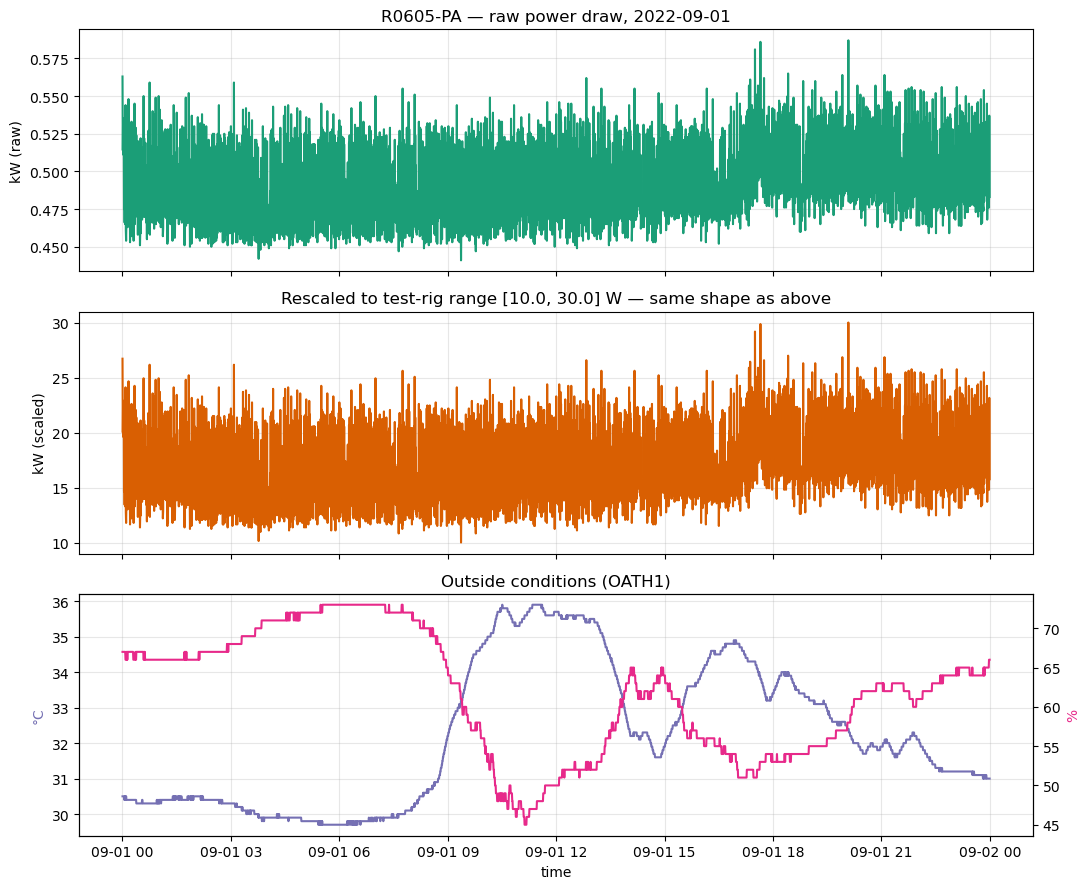

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(power_df['timestamp'], power_df['kW'], color='#1b9e77')
axes[0].set_ylabel('kW (raw)'); axes[0].set_title(f'{cfg.rack} — raw power draw, {cfg.date}')
axes[0].grid(alpha=.3)

axes[1].plot(power_df['timestamp'], power_df['kW_scaled'], color='#d95f02')
axes[1].set_ylabel('kW (scaled)')
axes[1].set_title(f'Rescaled to test-rig range [{cfg.scale_min}, {cfg.scale_max}] W — same shape as above')
axes[1].grid(alpha=.3)

ax_t = axes[2]
ax_t.plot(weather_df['timestamp'], weather_df['outside_temp_C'], color='#7570b3', label='outside temp (°C)')
ax_t.set_ylabel('°C', color='#7570b3'); ax_t.set_title(f'Outside conditions ({cfg.outside_sensor})')
ax_h = ax_t.twinx()
ax_h.plot(weather_df['timestamp'], weather_df['outside_humidity_pct'], color='#e7298a', label='humidity (%)')
ax_h.set_ylabel('%', color='#e7298a')
axes[2].grid(alpha=.3)
axes[2].set_xlabel('time')

plt.tight_layout(); plt.show()

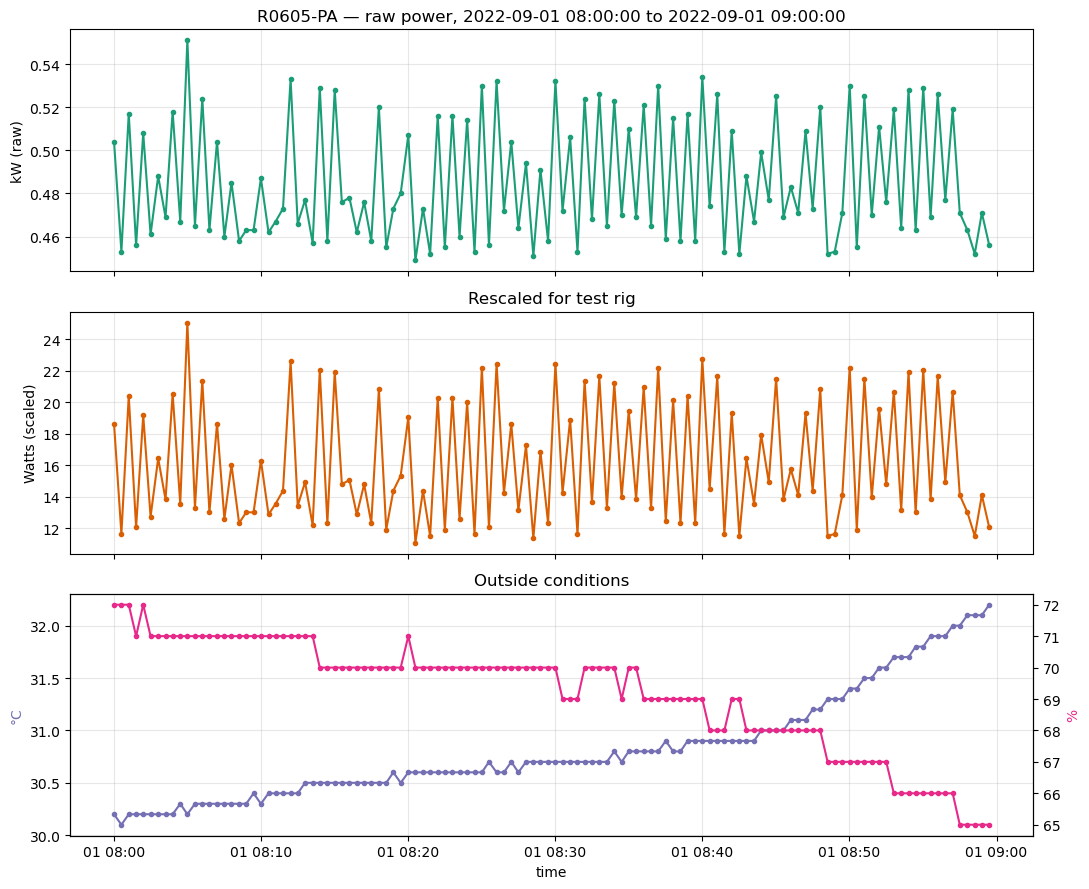

In [6]:
# ── config: pick any window inside the exported day ─────────────────────────
rack, date = 'R0605-PA', '2022-09-01'
start_time = f'{date} 08:00:00'
end_time   = f'{date} 09:00:00'          # 1-hour window; change as needed

out_dir = f'../data_for_spic/{rack}_{date}'
power = pd.read_csv(f'{out_dir}/power_load.csv', parse_dates=['timestamp'])
weather = pd.read_csv(f'{out_dir}/weather.csv', parse_dates=['timestamp'])

p = power[(power.timestamp >= start_time) & (power.timestamp <= end_time)]
w = weather[(weather.timestamp >= start_time) & (weather.timestamp <= end_time)]

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(p['timestamp'], p['kW'], color='#1b9e77', marker='o', markersize=3)
axes[0].set_ylabel('kW (raw)'); axes[0].set_title(f'{rack} — raw power, {start_time} to {end_time}')
axes[0].grid(alpha=.3)

axes[1].plot(p['timestamp'], p['kW_scaled'], color='#d95f02', marker='o', markersize=3)
axes[1].set_ylabel('Watts (scaled)'); axes[1].set_title('Rescaled for test rig')
axes[1].grid(alpha=.3)

ax_t = axes[2]
ax_t.plot(w['timestamp'], w['outside_temp_C'], color='#7570b3', marker='o', markersize=3, label='outside temp (°C)')
ax_t.set_ylabel('°C', color='#7570b3'); ax_t.set_title('Outside conditions')
ax_h = ax_t.twinx()
ax_h.plot(w['timestamp'], w['outside_humidity_pct'], color='#e7298a', marker='o', markersize=3, label='humidity (%)')
ax_h.set_ylabel('%', color='#e7298a')
axes[2].grid(alpha=.3)
axes[2].set_xlabel('time')

plt.tight_layout(); plt.show()

## 5. Export the windowed data to .mat (for MATLAB/Simulink)

Uses `p`/`w`/`out_dir` from the windowing cell above — re-run that cell first if
you change `start_time`/`end_time`.

In [7]:
from scipy.io import savemat

merged = pd.merge_asof(p.reset_index(drop=True), w.reset_index(drop=True), on='timestamp')

# time_s: elapsed seconds from the window start.
t0 = merged['timestamp'].iloc[0]
time_s = (merged['timestamp'] - t0).dt.total_seconds().to_numpy()

# datenum: MATLAB's absolute date-number (719529 = MATLAB datenum for 1970-01-01 UTC).
posix_s = merged['timestamp'].astype('int64').to_numpy() / 1e9
datenum = 719529.0 + posix_s / 86400.0

mat_path = Path(out_dir) / f'{rack}_{date}_{start_time[-8:].replace(":","")}_{end_time[-8:].replace(":","")}.mat'
savemat(mat_path, {
    'time_s': time_s,
    'datenum': datenum,
    'kW': merged['kW'].to_numpy(),
    'kW_scaled': merged['kW_scaled'].to_numpy(),
    'outside_temp_C': merged['outside_temp_C'].to_numpy(),
    'outside_humidity_pct': merged['outside_humidity_pct'].to_numpy(),
})

print(f'wrote {mat_path}  ({len(merged)} rows)')
print(f"kW_scaled range: {merged['kW_scaled'].min():.2f} .. {merged['kW_scaled'].max():.2f}")

wrote ..\data_for_spic\R0605-PA_2022-09-01\R0605-PA_2022-09-01_080000_090000.mat  (120 rows)
kW_scaled range: 11.10 .. 25.07


## 6. Additional export — scale [200, 600]

Same rack/date/data, a different target range. Reuses `export_spic_data()`
unmodified with a new config; written to a separate subfolder
(`data_for_spic/scaled_200_600/`) so the original `[10, 30]` export above is
untouched.

In [8]:
cfg_200_600 = SpicExportConfig(
    rack=cfg.rack,
    date=cfg.date,
    outside_sensor=cfg.outside_sensor,
    scale_min=200.0,
    scale_max=600.0,
    scale_scope=cfg.scale_scope,
    output_root=PROJECT_ROOT / 'data_for_spic' / 'scaled_200_600',
)

power_200_df, weather_200_df, (power_200_path, weather_200_path) = export_spic_data(cfg_200_600)
print(f'power_load.csv -> {power_200_path}  ({len(power_200_df):,} rows)')
print(f'weather.csv    -> {weather_200_path}  ({len(weather_200_df):,} rows)')
print(f"\nkW range: {power_200_df['kW'].min():.3f} .. {power_200_df['kW'].max():.3f}")
print(f"kW_scaled range: {power_200_df['kW_scaled'].min():.3f} .. {power_200_df['kW_scaled'].max():.3f}  "
      f"(target [{cfg_200_600.scale_min}, {cfg_200_600.scale_max}])")

power_load.csv -> D:\Research\Proposal\BESS\code\NTU\data_for_spic\scaled_200_600\R0605-PA_2022-09-01\power_load.csv  (2,880 rows)
weather.csv    -> D:\Research\Proposal\BESS\code\NTU\data_for_spic\scaled_200_600\R0605-PA_2022-09-01\weather.csv  (2,880 rows)

kW range: 0.441 .. 0.587
kW_scaled range: 200.000 .. 600.000  (target [200.0, 600.0])


### Visual check — [200, 600] export

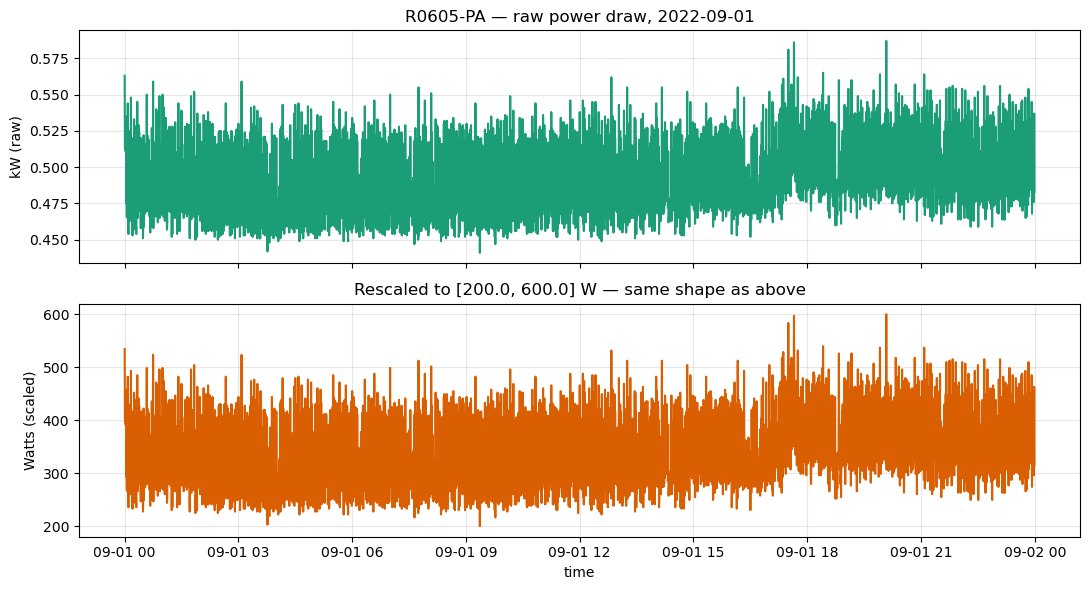

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(power_200_df['timestamp'], power_200_df['kW'], color='#1b9e77')
axes[0].set_ylabel('kW (raw)'); axes[0].set_title(f'{cfg_200_600.rack} — raw power draw, {cfg_200_600.date}')
axes[0].grid(alpha=.3)

axes[1].plot(power_200_df['timestamp'], power_200_df['kW_scaled'], color='#d95f02')
axes[1].set_ylabel('Watts (scaled)')
axes[1].set_title(f'Rescaled to [{cfg_200_600.scale_min}, {cfg_200_600.scale_max}] W — same shape as above')
axes[1].grid(alpha=.3); axes[1].set_xlabel('time')

plt.tight_layout(); plt.show()

## 7. Window + .mat export — [200, 600], 08:00–09:00

Same 08:00–09:00 window as the [10, 30] export above, this time from the
`power_200_df`/`weather_200_df` scale-[200,600] data, written alongside its CSVs
in `data_for_spic/scaled_200_600/{rack}_{date}/`.

In [10]:
p200 = power_200_df[(power_200_df.timestamp >= start_time) & (power_200_df.timestamp <= end_time)].reset_index(drop=True)
w200 = weather_200_df[(weather_200_df.timestamp >= start_time) & (weather_200_df.timestamp <= end_time)].reset_index(drop=True)
print(f'{len(p200)} rows in window {start_time} .. {end_time}')

120 rows in window 2022-09-01 08:00:00 .. 2022-09-01 09:00:00


In [11]:
merged200 = pd.merge_asof(p200, w200, on='timestamp')

t0_200 = merged200['timestamp'].iloc[0]
time_s_200 = (merged200['timestamp'] - t0_200).dt.total_seconds().to_numpy()
posix_s_200 = merged200['timestamp'].astype('int64').to_numpy() / 1e9
datenum_200 = 719529.0 + posix_s_200 / 86400.0

mat200_path = power_200_path.parent / f'{cfg_200_600.rack}_{cfg_200_600.date}_{start_time[-8:].replace(":","")}_{end_time[-8:].replace(":","")}.mat'
savemat(mat200_path, {
    'time_s': time_s_200,
    'datenum': datenum_200,
    'kW': merged200['kW'].to_numpy(),
    'kW_scaled': merged200['kW_scaled'].to_numpy(),
    'outside_temp_C': merged200['outside_temp_C'].to_numpy(),
    'outside_humidity_pct': merged200['outside_humidity_pct'].to_numpy(),
})

print(f'wrote {mat200_path}  ({len(merged200)} rows)')
print(f"kW_scaled range: {merged200['kW_scaled'].min():.2f} .. {merged200['kW_scaled'].max():.2f}")

wrote D:\Research\Proposal\BESS\code\NTU\data_for_spic\scaled_200_600\R0605-PA_2022-09-01\R0605-PA_2022-09-01_080000_090000.mat  (120 rows)
kW_scaled range: 221.92 .. 501.37
